### Prophet Baseline Forecasting — Çoklu Anahtar Kelime

##### Google Trends verisindeki her sayısal anahtar kelime sütunu ayrı bir zaman serisi olarak ele alınır.

##### Prophet her modelde yalnızca iki temel sütun bekler:
- `ds` → tarih
- `y` → o anda modellenen anahtar kelimenin trend skoru

##### Bu notebook her anahtar kelime için ayrı Prophet modeli kurar, zaman sırasını bozmadan train/test değerlendirmesi yapar, MAE ve RMSE hesaplar ve son aşamada yaklaşık 30 günlük tahmin üretir.


In [3]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [4]:
## Prophet zaman serisi tahmin modelini oluşturmak için kullanılır

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

from prophet import Prophet

c:\Users\sanug\OneDrive\Desktop\trend_forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [5]:
df = pd.read_csv("../data/processed/langchain_global_clean.csv")
df.head()

,date,Python,SQL
0,2023-08-06,62,31
1,2023-08-13,62,30
2,2023-08-20,66,30
3,2023-08-27,67,29
4,2023-09-03,68,29


In [6]:
# Tarih sütununu datetime formatına çeviriyoruz.

df["date"] = pd.to_datetime(
    df["date"]
)


## Zaman serisini kronolojik olarak sıralıyoruz.

df = (
    df
    .sort_values("date")
    .reset_index(drop=True)
)

df.tail()

,date,Python,SQL
153,2026-07-12,58,20
154,2026-07-19,61,25
155,2026-07-26,62,20
156,2026-08-02,57,18
157,2026-08-09,48,17


In [7]:
df.head()

,date,Python,SQL
0,2023-08-06,62,31
1,2023-08-13,62,30
2,2023-08-20,66,30
3,2023-08-27,67,29
4,2023-09-03,68,29


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    158 non-null    datetime64[us]
 1   Python  158 non-null    int64         
 2   SQL     158 non-null    int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 3.8 KB


In [9]:
## Modelleme öncesinde eksik değerleri kontrol ediyoruz.
df.isna().sum()

date      0
Python    0
SQL       0
dtype: int64

In [10]:
## Zaman serisini kronolojik sıraya göre sıralıyoruz.
## Zaman serisi modellerinde gözlemlerin sırasının korunması gerekir.
# reset_index(drop=True) ---> 5>2>8>1 indexi 0>1>2>3... diye yeniden düzenler
df = (df.sort_values("date").reset_index(drop=True))

In [11]:
## Prophet'in beklediği ds/y yapısını her anahtar kelime için ayrı oluşturuyoruz.
## date dışındaki sayısal sütunlar otomatik olarak anahtar kelime kabul edilir.
## Böylece yeni bir anahtar kelime sütunu eklendiğinde listeyi elle güncellemek gerekmez.

keywords = [
    col for col in df.columns
    if col != "date" and pd.api.types.is_numeric_dtype(df[col])
]

if not keywords:
    raise ValueError("date dışında sayısal bir anahtar kelime sütunu bulunamadı.")

prophet_dfs = {}

for keyword in keywords:
    prophet_dfs[keyword] = (
        df[["date", keyword]]
        .dropna()
        .rename(columns={
            "date": "ds",
            keyword: "y"
        })
        .sort_values("ds")
        .reset_index(drop=True)
    )

print("Modellenecek anahtar kelimeler:", keywords)


Modellenecek anahtar kelimeler: ['Python', 'SQL']


In [12]:
## Örnek olarak ilk anahtar kelimenin Prophet formatını kontrol ediyoruz.
sample_keyword = keywords[0]

print("Örnek anahtar kelime:", sample_keyword)
prophet_dfs[sample_keyword].head()


Örnek anahtar kelime: Python


,ds,y
0,2023-08-06,62
1,2023-08-13,62
2,2023-08-20,66
3,2023-08-27,67
4,2023-09-03,68


In [13]:
## Verimiz haftalık olduğu için son 4 gözlemi test olarak ayırıyoruz.
## 4 hafta yaklaşık 28 gün olduğu için 30 günlük tahmin hedefiyle uyumludur.
## Zaman serisinde shuffle kullanılmaz.

forecast_steps = 4

train_dfs = {}
test_dfs = {}

for keyword, prophet_df in prophet_dfs.items():
    if len(prophet_df) <= forecast_steps:
        raise ValueError(
            f"{keyword} için train/test ayırmaya yetecek kadar gözlem yok."
        )

    train_dfs[keyword] = prophet_df.iloc[:-forecast_steps].copy()
    test_dfs[keyword] = prophet_df.iloc[-forecast_steps:].copy()


In [14]:
## Her anahtar kelime için train/test tarih sınırlarını kontrol ediyoruz.

for keyword in keywords:
    train_df = train_dfs[keyword]
    test_df = test_dfs[keyword]

    print(f"\n{keyword}")
    print("Train başlangıç:", train_df["ds"].min())
    print("Train bitiş    :", train_df["ds"].max())
    print("Test başlangıç:", test_df["ds"].min())
    print("Test bitiş    :", test_df["ds"].max())



Python
Train başlangıç: 2023-08-06 00:00:00
Train bitiş    : 2026-07-12 00:00:00
Test başlangıç: 2026-07-19 00:00:00
Test bitiş    : 2026-08-09 00:00:00

SQL
Train başlangıç: 2023-08-06 00:00:00
Train bitiş    : 2026-07-12 00:00:00
Test başlangıç: 2026-07-19 00:00:00
Test bitiş    : 2026-08-09 00:00:00


In [15]:
## Her anahtar kelime için ayrı baseline Prophet modeli oluşturuyoruz.

models = {
    keyword: Prophet()
    for keyword in keywords
}


In [16]:
## Her modeli yalnızca kendi geçmiş train verisi üzerinde eğitiyoruz.

for keyword in keywords:
    models[keyword].fit(train_dfs[keyword])


14:10:25 - cmdstanpy - INFO - Chain [1] start processing
14:10:25 - cmdstanpy - INFO - Chain [1] done processing
14:10:25 - cmdstanpy - INFO - Chain [1] start processing
14:10:25 - cmdstanpy - INFO - Chain [1] done processing


In [17]:
## Test dönemindeki tarihleri her modele ayrı veriyoruz.

test_features = {
    keyword: test_dfs[keyword][["ds"]].copy()
    for keyword in keywords
}


In [18]:
## Her anahtar kelime için test tahminlerini üretiyoruz.

test_forecasts = {}

for keyword in keywords:
    test_forecasts[keyword] = models[keyword].predict(
        test_features[keyword]
    )


In [19]:
## yhat -> modelin ana tahmini
## yhat_lower -> tahmin aralığının alt sınırı
## yhat_upper -> tahmin aralığının üst sınırı

test_forecasts[sample_keyword][
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].head()


,ds,yhat,yhat_lower,yhat_upper
0,2026-07-19,75.166995,68.078701,82.586055
1,2026-07-26,77.738428,70.040614,85.153771
2,2026-08-02,79.802223,72.577862,86.628466
3,2026-08-09,81.516011,74.289091,88.951546


In [20]:
## Örnek anahtar kelimenin gerçek test değerleri.
test_dfs[sample_keyword]["y"]


154    61
155    62
156    57
157    48
Name: y, dtype: int64

In [21]:
## Örnek anahtar kelimenin tahmin değerleri.
test_forecasts[sample_keyword]["yhat"]


0    75.166995
1    77.738428
2    79.802223
3    81.516011
Name: yhat, dtype: float64

In [22]:
## Her anahtar kelime için gerçek ve tahmin edilen değerleri birleştiriyoruz.

results = {}

for keyword in keywords:
    results[keyword] = pd.DataFrame({
        "date": test_dfs[keyword]["ds"].values,
        "actual": test_dfs[keyword]["y"].values,
        "predicted": test_forecasts[keyword]["yhat"].values
    })


In [23]:
## Örnek anahtar kelimenin sonuçları.
results[sample_keyword]


,date,actual,predicted
0,2026-07-19,61,75.166995
1,2026-07-26,62,77.738428
2,2026-08-02,57,79.802223
3,2026-08-09,48,81.516011


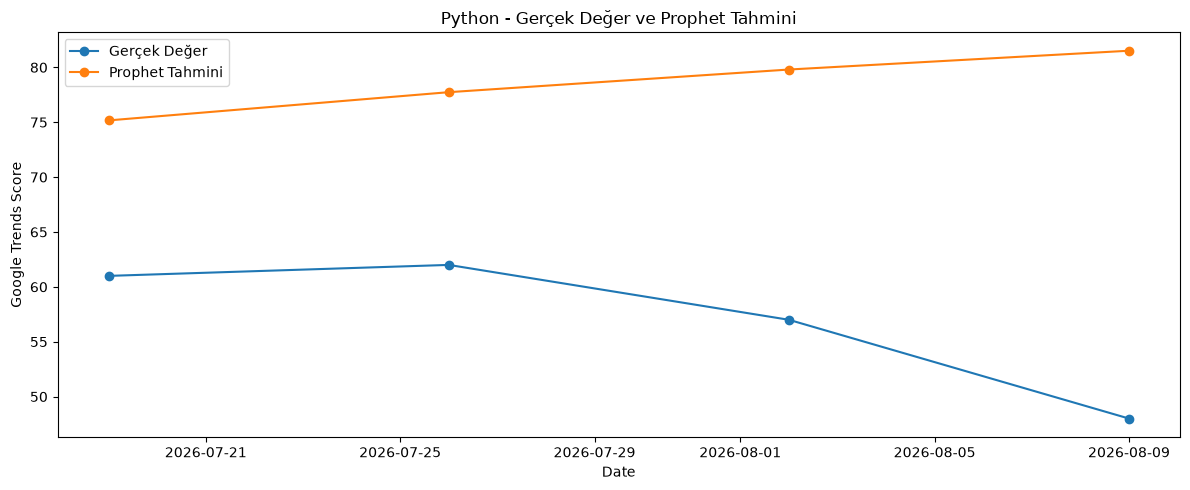

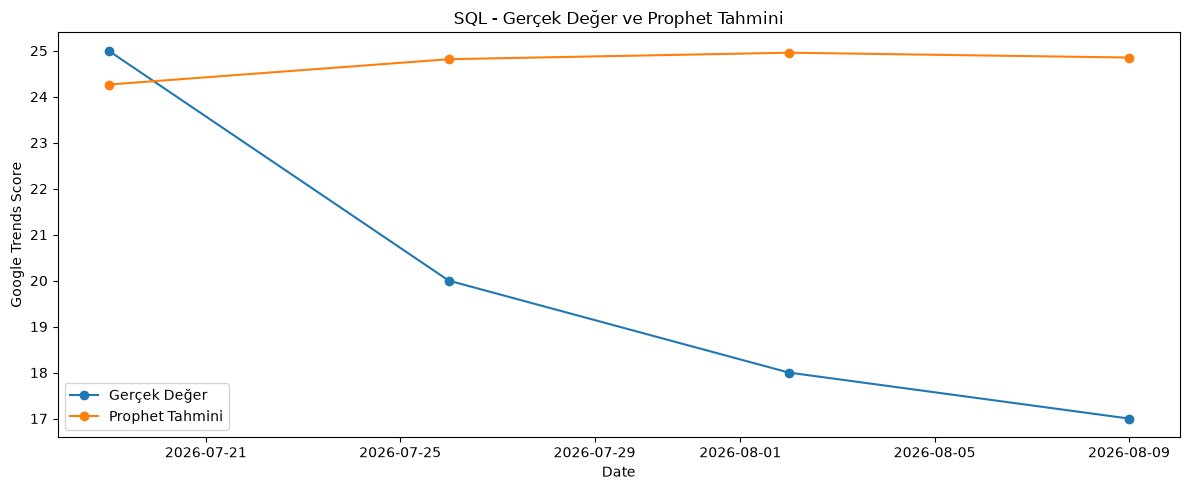

In [24]:
## Her anahtar kelime için gerçek değer ve Prophet tahminini çiziyoruz.

for keyword in keywords:
    results_df = results[keyword]

    plt.figure(figsize=(12, 5))

    plt.plot(
        results_df["date"],
        results_df["actual"],
        marker="o",
        label="Gerçek Değer"
    )

    plt.plot(
        results_df["date"],
        results_df["predicted"],
        marker="o",
        label="Prophet Tahmini"
    )

    plt.title(f"{keyword} - Gerçek Değer ve Prophet Tahmini")
    plt.xlabel("Date")
    plt.ylabel("Google Trends Score")
    plt.legend()
    plt.tight_layout()
    plt.show()


##### Prophet sonuçları artık her anahtar kelime için ayrı değerlendirilir.

##### Bazı anahtar kelimelerde ani trend kırılmaları Prophet tarafından iyi yakalanamayabilir. Bu nedenle MAE/RMSE değerlerini anahtar kelime bazında karşılaştırmak daha anlamlıdır.

##### Sonraki aşamada ARIMA/SARIMAX gibi alternatif modellerle aynı seriler üzerinde karşılaştırma yapılabilir.


In [25]:
## Tüm test sonuçlarını tek tabloda birleştiriyoruz.

all_results_df = pd.concat(
    [
        result_df.assign(keyword=keyword)
        for keyword, result_df in results.items()
    ],
    ignore_index=True
)[["keyword", "date", "actual", "predicted"]]

all_results_df


,keyword,date,actual,predicted
0,Python,2026-07-19,61,75.166995
1,Python,2026-07-26,62,77.738428
2,Python,2026-08-02,57,79.802223
3,Python,2026-08-09,48,81.516011
4,SQL,2026-07-19,25,24.264271
5,SQL,2026-07-26,20,24.815460
6,SQL,2026-08-02,18,24.957011
7,SQL,2026-08-09,17,24.851693


In [26]:
!pip install scikit-learn

In [27]:
## Prophet modelini hata perfonmasını değerlendirmek için 
## MAE ve RMSE metriklerini kullanıyoruz.

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [28]:
## Her anahtar kelime için MAE hesaplıyoruz.

mae_by_keyword = {
    keyword: mean_absolute_error(
        results[keyword]["actual"],
        results[keyword]["predicted"]
    )
    for keyword in keywords
}

mae_by_keyword


{'Python': 21.555914304199636, 'SQL': 5.0899733897399235}

In [29]:
## Her anahtar kelime için RMSE hesaplıyoruz.

rmse_by_keyword = {
    keyword: root_mean_squared_error(
        results[keyword]["actual"],
        results[keyword]["predicted"]
    )
    for keyword in keywords
}

rmse_by_keyword


{'Python': 22.867368961037606, 'SQL': 5.783144569396955}

In [30]:
## MAE ve RMSE değerlerini tek tabloda karşılaştırıyoruz.

metrics_df = pd.DataFrame({
    "keyword": keywords,
    "MAE": [mae_by_keyword[k] for k in keywords],
    "RMSE": [rmse_by_keyword[k] for k in keywords]
}).sort_values("MAE").reset_index(drop=True)

metrics_df.round(2)


,keyword,MAE,RMSE
0,SQL,5.09,5.78
1,Python,21.56,22.87


##### MAE ve RMSE değerleri artık her anahtar kelime için ayrı hesaplanmaktadır.

##### Daha düşük MAE/RMSE, ilgili anahtar kelimenin test döneminde Prophet tarafından daha iyi tahmin edildiğini gösterir. RMSE'nin MAE'den belirgin biçimde büyük olması bazı dönemlerde daha büyük tahmin hataları bulunduğuna işaret eder.


In [31]:
## Her anahtar kelimenin tahmin hatasını hesaplıyoruz.

for keyword in keywords:
    results[keyword]["error"] = (
        results[keyword]["actual"] - results[keyword]["predicted"]
    )


In [32]:
## Hatanın yönünden bağımsız büyüklüğünü hesaplıyoruz.

for keyword in keywords:
    results[keyword]["absolute_error"] = (
        results[keyword]["error"].abs()
    )


In [33]:
## Hata sütunları eklenmiş tüm test sonuçlarını tek tabloda topluyoruz.

all_results_df = pd.concat(
    [
        result_df.assign(keyword=keyword)
        for keyword, result_df in results.items()
    ],
    ignore_index=True
)[
    ["keyword", "date", "actual", "predicted", "error", "absolute_error"]
]

all_results_df


,keyword,date,actual,predicted,error,absolute_error
0,Python,2026-07-19,61,75.166995,-14.166995,14.166995
1,Python,2026-07-26,62,77.738428,-15.738428,15.738428
2,Python,2026-08-02,57,79.802223,-22.802223,22.802223
3,Python,2026-08-09,48,81.516011,-33.516011,33.516011
4,SQL,2026-07-19,25,24.264271,0.735729,0.735729
5,SQL,2026-07-26,20,24.815460,-4.815460,4.815460
6,SQL,2026-08-02,18,24.957011,-6.957011,6.957011
7,SQL,2026-08-09,17,24.851693,-7.851693,7.851693


In [34]:
## Tüm anahtar kelimeler içinde en büyük 10 tahmin hatası.

all_results_df.nlargest(10, "absolute_error")


,keyword,date,actual,predicted,error,absolute_error
3,Python,2026-08-09,48,81.516011,-33.516011,33.516011
2,Python,2026-08-02,57,79.802223,-22.802223,22.802223
1,Python,2026-07-26,62,77.738428,-15.738428,15.738428
0,Python,2026-07-19,61,75.166995,-14.166995,14.166995
7,SQL,2026-08-09,17,24.851693,-7.851693,7.851693
6,SQL,2026-08-02,18,24.957011,-6.957011,6.957011
5,SQL,2026-07-26,20,24.815460,-4.815460,4.815460
4,SQL,2026-07-19,25,24.264271,0.735729,0.735729


In [35]:
## Prophet modelinin zaman serisine uygun cross-validation
## ve perfonmans değerlendirme araçlarını kullanıyoruz.

from prophet.diagnostics import (cross_validation, performance_metrics)

In [36]:
## Cross-validation için her anahtar kelimeyi tüm geçmiş verisiyle ayrı modelliyoruz.

cv_models = {}

for keyword in keywords:
    cv_models[keyword] = Prophet()
    cv_models[keyword].fit(prophet_dfs[keyword])


14:10:28 - cmdstanpy - INFO - Chain [1] start processing
14:10:29 - cmdstanpy - INFO - Chain [1] done processing
14:10:29 - cmdstanpy - INFO - Chain [1] start processing
14:10:29 - cmdstanpy - INFO - Chain [1] done processing


In [37]:
## Her anahtar kelime için Time-Series Cross-Validation uyguluyoruz.
##
## initial: ilk eğitim döneminin minimum uzunluğu
## period : cutoff noktaları arasındaki mesafe
## horizon: her cutoff sonrasında tahmin edilen dönem

cv_results = {}

for keyword in keywords:
    print(f"Cross-validation: {keyword}")

    cv_results[keyword] = cross_validation(
        cv_models[keyword],
        initial="730 days",
        period="90 days",
        horizon="90 days"
    )


Cross-validation: Python


  0%|          | 0/4 [00:00<?, ?it/s]14:10:29 - cmdstanpy - INFO - Chain [1] start processing
14:10:29 - cmdstanpy - INFO - Chain [1] done processing
 25%|██▌       | 1/4 [00:00<00:00,  4.05it/s]14:10:29 - cmdstanpy - INFO - Chain [1] start processing
14:10:29 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 2/4 [00:00<00:00,  4.28it/s]14:10:29 - cmdstanpy - INFO - Chain [1] start processing
14:10:29 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████▌  | 3/4 [00:00<00:00,  4.20it/s]14:10:30 - cmdstanpy - INFO - Chain [1] start processing
14:10:30 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 4/4 [00:00<00:00,  4.23it/s]


Cross-validation: SQL


  0%|          | 0/4 [00:00<?, ?it/s]14:10:30 - cmdstanpy - INFO - Chain [1] start processing
14:10:30 - cmdstanpy - INFO - Chain [1] done processing
 25%|██▌       | 1/4 [00:00<00:00,  4.61it/s]14:10:30 - cmdstanpy - INFO - Chain [1] start processing
14:10:30 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 2/4 [00:00<00:00,  4.47it/s]14:10:30 - cmdstanpy - INFO - Chain [1] start processing
14:10:30 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████▌  | 3/4 [00:00<00:00,  4.41it/s]14:10:31 - cmdstanpy - INFO - Chain [1] start processing
14:10:31 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 4/4 [00:00<00:00,  4.49it/s]


In [38]:
## initial="730 days" yaklaşık 2 yıllık ilk eğitim dönemi demek.

## 2023 ---------------- 2025
##     yaklaşık 2 yıl

In [39]:
## Örnek anahtar kelimenin cross-validation çıktısı.
cv_results[sample_keyword].head()


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2025-08-17,54.035752,49.970635,58.362842,71,2025-08-14
1,2025-08-24,53.753893,49.517051,58.029267,66,2025-08-14
2,2025-08-31,54.181015,50.016104,58.135844,67,2025-08-14
3,2025-09-07,55.337137,51.470930,59.334151,66,2025-08-14
4,2025-09-14,56.552268,52.509630,60.411444,65,2025-08-14


In [40]:
## Cross-validation sonuçlarından performans metriklerini hesaplıyoruz.

cv_metrics = {
    keyword: performance_metrics(cv_results[keyword])
    for keyword in keywords
}


In [41]:
## Örnek anahtar kelimede farklı forecast horizonlarındaki MAE/RMSE.

cv_metrics[sample_keyword][["horizon", "mae", "rmse"]].head(10)


,horizon,mae,rmse
0,10 days,8.227975,10.678618
1,11 days,5.976747,7.936766
2,12 days,6.544371,8.054445
3,13 days,11.586632,13.924481
4,17 days,11.849826,14.152476
5,18 days,10.925855,13.488184
6,19 days,11.311343,13.677534
7,20 days,16.504627,18.811758
8,24 days,13.557353,15.735228
9,25 days,12.448120,15.010359


In [42]:
## Her anahtar kelimenin ortalama cross-validation MAE ve RMSE değerleri.

cv_summary = pd.DataFrame([
    {
        "keyword": keyword,
        "cv_mae": cv_metrics[keyword]["mae"].mean(),
        "cv_rmse": cv_metrics[keyword]["rmse"].mean()
    }
    for keyword in keywords
]).sort_values("cv_mae").reset_index(drop=True)

cv_summary.round(2)


,keyword,cv_mae,cv_rmse
0,SQL,2.92,3.16
1,Python,11.97,13.54


##### Cross-validation sonuçları anahtar kelimeler arasında karşılaştırılabilir.

##### Prophet bazı serilerde istikrarlı çalışırken, trend kırılması veya ani sıçrama bulunan serilerde daha yüksek hata üretebilir. Bu yüzden tek bir genel hata değeri yerine anahtar kelime bazındaki sonuçlara bakmak daha doğrudur.


### Yaklaşık 30 Günlük Tahmin


In [43]:
## Yaklaşık 30 günlük tahmin performansını geçmiş dönemlerde test ediyoruz.

cv_results_30 = {}

for keyword in keywords:
    print(f"30 günlük cross-validation: {keyword}")

    cv_results_30[keyword] = cross_validation(
        cv_models[keyword],
        initial="730 days",
        period="90 days",
        horizon="30 days"
    )


30 günlük cross-validation: Python


  0%|          | 0/4 [00:00<?, ?it/s]14:10:31 - cmdstanpy - INFO - Chain [1] start processing
14:10:31 - cmdstanpy - INFO - Chain [1] done processing
 25%|██▌       | 1/4 [00:00<00:00,  4.49it/s]14:10:31 - cmdstanpy - INFO - Chain [1] start processing
14:10:31 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 2/4 [00:00<00:00,  4.30it/s]14:10:31 - cmdstanpy - INFO - Chain [1] start processing
14:10:31 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████▌  | 3/4 [00:00<00:00,  4.50it/s]14:10:32 - cmdstanpy - INFO - Chain [1] start processing
14:10:32 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 4/4 [00:00<00:00,  4.48it/s]


30 günlük cross-validation: SQL


  0%|          | 0/4 [00:00<?, ?it/s]14:10:32 - cmdstanpy - INFO - Chain [1] start processing
14:10:32 - cmdstanpy - INFO - Chain [1] done processing
 25%|██▌       | 1/4 [00:00<00:00,  4.63it/s]14:10:32 - cmdstanpy - INFO - Chain [1] start processing
14:10:32 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 2/4 [00:00<00:00,  4.53it/s]14:10:32 - cmdstanpy - INFO - Chain [1] start processing
14:10:32 - cmdstanpy - INFO - Chain [1] done processing
 75%|███████▌  | 3/4 [00:00<00:00,  4.61it/s]14:10:33 - cmdstanpy - INFO - Chain [1] start processing
14:10:33 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 4/4 [00:00<00:00,  4.56it/s]


In [44]:
## 30 günlük cross-validation sonuçlarını anahtar kelime bazında özetliyoruz.

cv_metrics_30 = {
    keyword: performance_metrics(
        cv_results_30[keyword],
        rolling_window=1
    )
    for keyword in keywords
}

cv_30_summary = pd.DataFrame([
    {
        "keyword": keyword,
        "mae_30d": cv_metrics_30[keyword]["mae"].mean(),
        "rmse_30d": cv_metrics_30[keyword]["rmse"].mean()
    }
    for keyword in keywords
]).sort_values("mae_30d").reset_index(drop=True)

cv_30_summary.round(2)


,keyword,mae_30d,rmse_30d
0,SQL,3.45,4.37
1,Python,13.11,16.72


In [45]:
## Değerlendirme tamamlandıktan sonra her anahtar kelime için
## tüm geçmiş veriyi kullanacak final Prophet modelini oluşturuyoruz.

final_models = {
    keyword: Prophet()
    for keyword in keywords
}


In [46]:
## Final modellerini tüm geçmiş veri üzerinde eğitiyoruz.

for keyword in keywords:
    final_models[keyword].fit(prophet_dfs[keyword])


14:10:33 - cmdstanpy - INFO - Chain [1] start processing
14:10:33 - cmdstanpy - INFO - Chain [1] done processing
14:10:33 - cmdstanpy - INFO - Chain [1] start processing
14:10:33 - cmdstanpy - INFO - Chain [1] done processing


In [47]:
## Veri haftalık olduğu için yaklaşık 30 günlük geleceği 4 hafta olarak tahmin ediyoruz.
## freq="W-SUN" gelecek gözlemleri pazar günlerine yerleştirir.

future_dates = {}

for keyword in keywords:
    future_dates[keyword] = final_models[keyword].make_future_dataframe(
        periods=4,
        freq="W-SUN"
    )


In [48]:
## Örnek anahtar kelimenin oluşturulan gelecek tarihleri.
future_dates[sample_keyword].tail(10)


,ds
152,2026-07-05
153,2026-07-12
154,2026-07-19
155,2026-07-26
156,2026-08-02
157,2026-08-09
158,2026-08-16
159,2026-08-23
160,2026-08-30
161,2026-09-06


In [49]:
## Her anahtar kelime için geçmiş + gelecek tahminlerini üretiyoruz.

future_forecasts = {}

for keyword in keywords:
    future_forecasts[keyword] = final_models[keyword].predict(
        future_dates[keyword]
    )


In [50]:
## Örnek anahtar kelimenin tahminleri.
future_forecasts[sample_keyword][
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(10)


,ds,yhat,yhat_lower,yhat_upper
152,2026-07-05,69.861149,61.745996,78.280976
153,2026-07-12,68.134124,59.700427,76.055959
154,2026-07-19,67.393858,59.460952,75.169757
155,2026-07-26,66.950873,58.360375,74.708841
156,2026-08-02,67.433155,58.655743,75.801214
157,2026-08-09,69.809720,61.864859,77.577670
158,2026-08-16,73.653930,65.829508,82.570121
159,2026-08-23,77.093868,69.137315,85.738876
160,2026-08-30,78.651524,70.178560,87.059378
161,2026-09-06,78.698430,70.384084,87.086392


In [51]:
## Her anahtar kelime için son gerçek gözlem tarihini belirliyoruz.

last_dates = {
    keyword: prophet_dfs[keyword]["ds"].max()
    for keyword in keywords
}

last_dates


{'Python': Timestamp('2026-08-09 00:00:00'),
 'SQL': Timestamp('2026-08-09 00:00:00')}

In [52]:
## Yalnızca gerçek verinin bittiği tarihten sonraki tahminleri seçiyoruz.

future_only = {}

for keyword in keywords:
    last_date = last_dates[keyword]

    temp = future_forecasts[keyword].loc[
        future_forecasts[keyword]["ds"] > last_date,
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].copy()

    temp["keyword"] = keyword
    future_only[keyword] = temp

future_only_df = pd.concat(
    future_only.values(),
    ignore_index=True
)[["keyword", "ds", "yhat", "yhat_lower", "yhat_upper"]]


In [53]:
## Tüm anahtar kelimelerin yaklaşık 30 günlük gelecek tahminleri.
future_only_df


,keyword,ds,yhat,yhat_lower,yhat_upper
0,Python,2026-08-16,73.653930,65.829508,82.570121
1,Python,2026-08-23,77.093868,69.137315,85.738876
2,Python,2026-08-30,78.651524,70.178560,87.059378
3,Python,2026-09-06,78.698430,70.384084,87.086392
4,SQL,2026-08-16,22.603919,20.080802,25.168820
5,SQL,2026-08-23,23.199589,20.693693,25.531991
6,SQL,2026-08-30,23.509163,20.977679,25.919118
7,SQL,2026-09-06,23.709796,21.169129,25.965299


In [54]:
## Tahmin sonuçlarını iki ondalık basamağa yuvarlıyoruz.

forecast_columns = ["yhat", "yhat_lower", "yhat_upper"]

future_only_df[forecast_columns] = (
    future_only_df[forecast_columns].round(2)
)

future_only_df


,keyword,ds,yhat,yhat_lower,yhat_upper
0,Python,2026-08-16,73.65,65.83,82.57
1,Python,2026-08-23,77.09,69.14,85.74
2,Python,2026-08-30,78.65,70.18,87.06
3,Python,2026-09-06,78.70,70.38,87.09
4,SQL,2026-08-16,22.60,20.08,25.17
5,SQL,2026-08-23,23.20,20.69,25.53
6,SQL,2026-08-30,23.51,20.98,25.92
7,SQL,2026-09-06,23.71,21.17,25.97


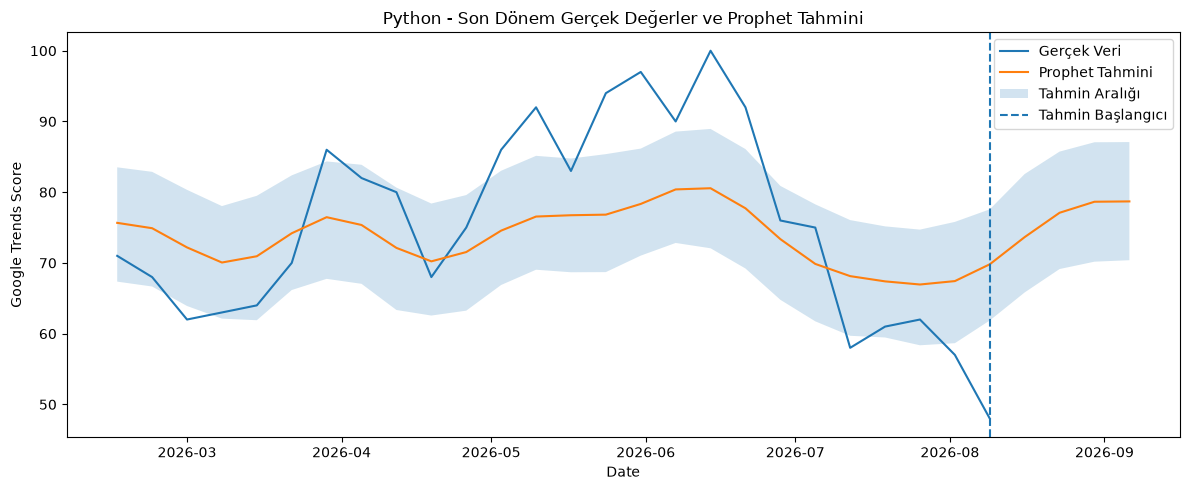

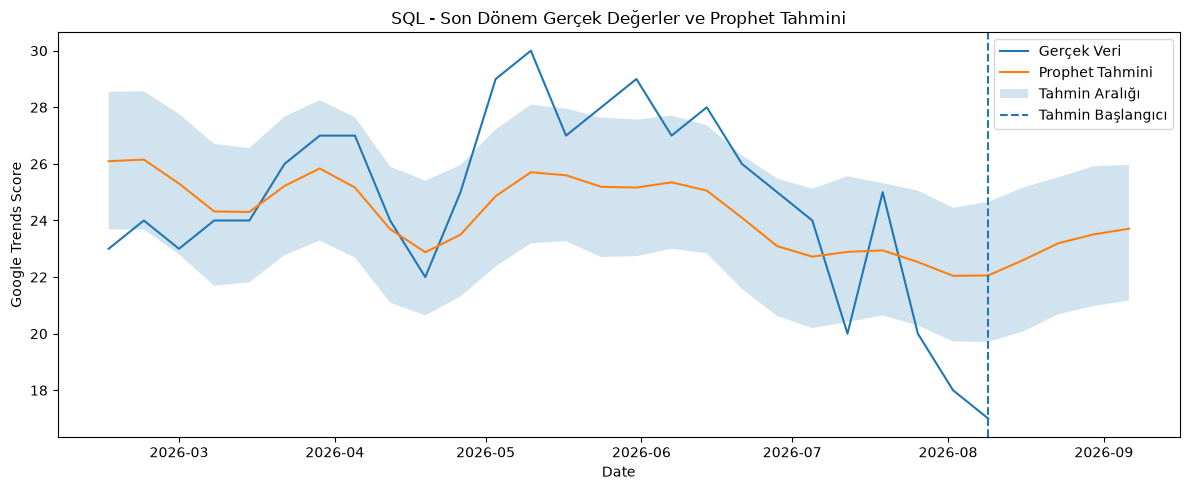

In [55]:
## Her anahtar kelime için son 180 günlük gerçek veri ile
## geçmiş + gelecek Prophet tahminini çiziyoruz.

for keyword in keywords:
    prophet_df = prophet_dfs[keyword]
    future_forecast = future_forecasts[keyword]
    last_date = last_dates[keyword]

    recent_start = last_date - pd.Timedelta(days=180)

    recent_actual = prophet_df[
        prophet_df["ds"] >= recent_start
    ].copy()

    recent_forecast = future_forecast[
        future_forecast["ds"] >= recent_start
    ].copy()

    plt.figure(figsize=(12, 5))

    plt.plot(
        recent_actual["ds"],
        recent_actual["y"],
        label="Gerçek Veri"
    )

    plt.plot(
        recent_forecast["ds"],
        recent_forecast["yhat"],
        label="Prophet Tahmini"
    )

    plt.fill_between(
        recent_forecast["ds"],
        recent_forecast["yhat_lower"],
        recent_forecast["yhat_upper"],
        alpha=0.2,
        label="Tahmin Aralığı"
    )

    plt.axvline(
        x=last_date,
        linestyle="--",
        label="Tahmin Başlangıcı"
    )

    plt.title(
        f"{keyword} - Son Dönem Gerçek Değerler ve Prophet Tahmini"
    )
    plt.xlabel("Date")
    plt.ylabel("Google Trends Score")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [56]:
## Nihai yaklaşık 30 günlük tahmin tablosu.
future_only_df


,keyword,ds,yhat,yhat_lower,yhat_upper
0,Python,2026-08-16,73.65,65.83,82.57
1,Python,2026-08-23,77.09,69.14,85.74
2,Python,2026-08-30,78.65,70.18,87.06
3,Python,2026-09-06,78.70,70.38,87.09
4,SQL,2026-08-16,22.60,20.08,25.17
5,SQL,2026-08-23,23.20,20.69,25.53
6,SQL,2026-08-30,23.51,20.98,25.92
7,SQL,2026-09-06,23.71,21.17,25.97
